<a href="https://colab.research.google.com/github/if3ol/CS510/blob/main/Copy_of_pipeline_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Narrative Misinformation Tracking System

**Author:** Ifeoluwa Olusola

### Pipeline stages
- [ ] **Step 1** — Mount Google Drive
- [ ] **Step 2** — Install dependencies
- [ ] **Step 3** — Collect articles (GDELT)
- [ ] **Step 4** — Clean text
- [ ] **Step 5** — Embed with Sentence-BERT
- [ ] **Step 6** — Cluster into narratives
- [ ] **Step 7** — Visualize evolution
---
**Run cells in order, top to bottom.  
Do not skip cells — each one depends on the one before it.**

##  Config — edit this before running anything

In [ ]:
#  Search settings
QUERY      = "covid lab leak"   # the misinformation narrative to track
START_DATE = "20210101"         # YYYYMMDD — when the narrative started gaining traction
END_DATE   = "20230101"         # YYYYMMDD — end of collection window

#  Storage
# All data is saved here on your Google Drive so it survives session restarts
DRIVE_DATA_DIR = "/content/drive/MyDrive/misinformation-tracker/data/raw"

print("Config ready.")
print(f"  Query : {QUERY}")
print(f"  Range : {START_DATE} to {END_DATE}")

Config ready.
  Query : covid lab leak
  Range : 20210101 to 20230101


##  Step 1 — Mount Google Drive


In [ ]:
from google.colab import drive
import os

drive.mount("/content/drive")

os.makedirs(DRIVE_DATA_DIR, exist_ok=True)

print(f"Drive mounted.")
print(f"Data will be saved to: {DRIVE_DATA_DIR}")

Mounted at /content/drive
Drive mounted.
Data will be saved to: /content/drive/MyDrive/misinformation-tracker/data/raw


##  Step 2 — Install Dependencies


In [ ]:
!pip install -q requests sentence-transformers scikit-learn pandas tqdm
!pip install -q spacy
!python -m spacy download en_core_web_sm
print("Dependencies ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 38.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Dependencies ready.


##  Step 3 — Collect Articles from GDELT

[GDELT](https://www.gdeltproject.org/) monitors news across thousands of outlets worldwide.  
It's completely free and requires no API key.

We collect in **monthly windows** so we can later track how the narrative evolves over time.  
Each window fetches up to 250 articles

In [ ]:
import requests
import time
import json
import csv
import os
from datetime import datetime, timedelta, timezone
from urllib.parse import urlencode

#  GDELT API

GDELT_BASE    = "https://api.gdeltproject.org/api/v2/doc/doc"
REQUEST_DELAY = 1.5   # seconds between requests — keeps us within GDELT rate limits


def build_url(query, start, end, maxrecords=250):
    params = {
        "query":         query,
        "mode":          "artlist",
        "maxrecords":    min(maxrecords, 250),
        "startdatetime": start.ljust(14, "0"),
        "enddatetime":   end.ljust(14, "0"),
        "sort":          "DateDesc",
        "format":        "json",
    }
    return f"{GDELT_BASE}?{urlencode(params)}"


def fetch_window(query, start, end, maxrecords=250):
    url = build_url(query, start, end, maxrecords)
    try:
        r = requests.get(url, timeout=15)
        r.raise_for_status()
        return r.json().get("articles", [])
    except Exception as e:
        print(f"  [Error] {e}")
        return []


def parse_article(raw, window_label):
    seen_date = raw.get("seendate", "")
    try:
        dt = datetime.strptime(seen_date, "%Y%m%dT%H%M%SZ").replace(tzinfo=timezone.utc)
        created_utc = dt.isoformat()
    except ValueError:
        created_utc = seen_date

    title = raw.get("title", "").strip()
    return {
        "id":          raw.get("url", ""),
        "domain":      raw.get("domain", ""),
        "title":       title,
        "full_text":   title,          # we embed on titles — concise and information-dense
        "language":    raw.get("language", ""),
        "url":         raw.get("url", ""),
        "created_utc": created_utc,
        "window":      window_label,   # monthly bucket — used for timeline analysis
    }


def make_windows(start, end, window_days=30):
    fmt = "%Y%m%d"
    current = datetime.strptime(start, fmt)
    end_dt  = datetime.strptime(end, fmt)
    windows = []
    while current < end_dt:
        win_end = min(current + timedelta(days=window_days), end_dt)
        windows.append((current.strftime(fmt), win_end.strftime(fmt), current.strftime("%Y-%m")))
        current = win_end
    return windows


def collect(query, start, end, max_per_window=250, output_dir="/content", english_only=True):
    os.makedirs(output_dir, exist_ok=True)
    actual_query = f"{query} sourcelang:eng" if english_only else query
    windows      = make_windows(start, end)
    all_articles = []
    seen_ids     = set()

    print(f"Query      : \"{query}\"")
    print(f"Date range : {start} to {end}")
    print(f"Windows    : {len(windows)} monthly buckets")
    print(f"Max/window : {max_per_window}")
    print("-" * 50)

    for win_start, win_end, label in windows:
        print(f"[{label}]  fetching...", end=" ")
        raw_articles = fetch_window(actual_query, win_start, win_end, max_per_window)

        if not raw_articles:
            print("0 articles")
            time.sleep(REQUEST_DELAY)
            continue

        parsed  = [parse_article(a, label) for a in raw_articles]
        new     = [a for a in parsed if a["id"] not in seen_ids]
        for a in new:
            seen_ids.add(a["id"])

        all_articles.extend(new)
        print(f"{len(new)} articles  (total: {len(all_articles)})")
        time.sleep(REQUEST_DELAY)

    print("-" * 50)
    print(f"Done. {len(all_articles)} articles collected.")

    # Save to Drive
    ts         = datetime.now().strftime("%Y%m%d_%H%M%S")
    safe_query = query.replace(" ", "_")
    json_path  = os.path.join(output_dir, f"{safe_query}_{ts}.json")
    csv_path   = os.path.join(output_dir, f"{safe_query}_{ts}.csv")

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(all_articles, f, indent=2, ensure_ascii=False)

    if all_articles:
        with open(csv_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=all_articles[0].keys())
            writer.writeheader()
            writer.writerows(all_articles)

    print(f"\nSaved to Drive:")
    print(f"  JSON -> {json_path}")
    print(f"  CSV  -> {csv_path}")

    return all_articles

print("Collector ready.")

Collector ready.


In [ ]:
# Run the collector
articles = collect(
    query          = QUERY,
    start          = START_DATE,
    end            = END_DATE,
    max_per_window = 250,
    output_dir     = DRIVE_DATA_DIR,
    english_only   = True,
)

Query      : "covid lab leak"
Date range : 20210101 to 20230101
Windows    : 25 monthly buckets
Max/window : 250
--------------------------------------------------
[2021-01]  fetching...   [Error] HTTPSConnectionPool(host='api.gdeltproject.org', port=443): Max retries exceeded with url: /api/v2/doc/doc?query=covid+lab+leak+sourcelang%3Aeng&mode=artlist&maxrecords=250&startdatetime=20210101000000&enddatetime=20210131000000&sort=DateDesc&format=json (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x7ce36676f320>, 'Connection to api.gdeltproject.org timed out. (connect timeout=15)'))
0 articles
[2021-01]  fetching...   [Error] HTTPSConnectionPool(host='api.gdeltproject.org', port=443): Max retries exceeded with url: /api/v2/doc/doc?query=covid+lab+leak+sourcelang%3Aeng&mode=artlist&maxrecords=250&startdatetime=20210131000000&enddatetime=20210302000000&sort=DateDesc&format=json (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x7ce36

##  Step 3b — Inspect the collected data
Run this after collection to make sure everything looks right before moving on.

In [ ]:
import pandas as pd

df = pd.DataFrame(articles)

print(f"Total articles : {len(df)}")
print(f"Columns        : {list(df.columns)}")
print(f"Date range     : {df['created_utc'].min()} to {df['created_utc'].max()}")
print(f"Unique domains : {df['domain'].nunique()}")
print()
print("Articles per month:")
print(df.groupby('window').size().to_string())
print()
print("Sample articles:")
df[['window', 'domain', 'title']].head(10)

Total articles : 2888
Columns        : ['id', 'domain', 'title', 'full_text', 'language', 'url', 'created_utc', 'window']
Date range     : 2021-04-11T15:15:00+00:00 to 2023-01-01T23:30:00+00:00
Unique domains : 869

Articles per month:
window
2021-04    250
2021-05    250
2021-06    250
2021-07    250
2021-09    249
2021-10    250
2021-11    250
2021-12    249
2022-02    250
2022-03    200
2022-06    145
2022-11    250
2022-12     45

Sample articles:


,window,domain,title
0,2021-04,thestreetjournal.org,"Breaking News | EU Report Accusing China , Rus..."
1,2021-04,theepochtimes.com,WHO Team Investigating Pandemic Origins Must H...
2,2021-04,wftw.com,WHO Should Look Beyond Animals on COVID Origin...
3,2021-04,klif.com,WHO Should Look Beyond Animals on COVID Origin...
4,2021-04,kmjnow.com,WHO Should Look Beyond Animals on COVID Origin...
5,2021-04,1490wosh.com,WHO Should Look Beyond Animals on COVID Origin...
6,2021-04,kvor.com,WHO Should Look Beyond Animals on COVID Origin...
7,2021-04,wtma.com,WHO Should Look Beyond Animals on COVID Origin...
8,2021-04,980waav.com,WHO Should Look Beyond Animals on COVID Origin...
9,2021-04,wmal.com,WHO Should Look Beyond Animals on COVID Origin...


---
##  Collection complete

The data is saved to Google Drive and will be there when you reopen this session.



In [ ]:
#  Step 4: Clean & Filter

import re
import pandas as pd

# Keywords that should appear in a genuine lab-leak article
# An article must contain at least one of these to pass the filter
RELEVANCE_KEYWORDS = [
    "lab leak", "wuhan lab", "wuhan institute", "gain of function",
    "lab origin", "laboratory origin", "virus origin", "covid origin",
    "bioweapon", "engineered virus", "fauci", "virology institute",
    "natural origin", "zoonotic", "bat coronavirus", "lab theory"
]

def clean_title(text):
    """Normalize a title for embedding."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", "", text)          # remove URLs
    text = re.sub(r"[^a-z0-9\s\-\']", " ", text) # remove special chars
    text = re.sub(r"\s+", " ", text).strip()      # collapse whitespace
    return text

def is_relevant(title):
    """Return True if the title contains at least one relevance keyword."""
    title_lower = title.lower()
    return any(kw in title_lower for kw in RELEVANCE_KEYWORDS)

# Load from Drive (in case session restarted)
# If articles is still in memory from Step 3, this is a no-op
if 'df' not in dir() or len(df) == 0:
    import glob, json
    files = sorted(glob.glob(f"{DRIVE_DATA_DIR}/*.json"))
    latest = files[-1]
    with open(latest) as f:
        articles = json.load(f)
    df = pd.DataFrame(articles)
    print(f"Loaded {len(df)} articles from {latest}")

df_clean = df.copy()

# 1. Drop rows with empty titles
df_clean = df_clean[df_clean["title"].str.strip().astype(bool)]

# 2. Clean and normalize title text
df_clean["clean_text"] = df_clean["title"].apply(clean_title)

# 3. Filter to relevant articles only
before = len(df_clean)
df_clean = df_clean[df_clean["title"].apply(is_relevant)].reset_index(drop=True)
after = len(df_clean)

# 4. Drop duplicate titles (same story picked up by multiple outlets)
df_clean = df_clean.drop_duplicates(subset="clean_text").reset_index(drop=True)
final = len(df_clean)

print(f"Before filtering  : {before}")
print(f"After relevance   : {after}  ({before - after} noisy articles removed)")
print(f"After dedup       : {final}  ({after - final} duplicate titles removed)")
print(f"\nMonthly distribution after cleaning:")
print(df_clean.groupby("window").size().to_string())
print(f"\nSample cleaned titles:")
df_clean[["window", "domain", "clean_text"]].head(10)

Before filtering  : 2888
After relevance   : 759  (2129 noisy articles removed)
After dedup       : 453  (306 duplicate titles removed)

Monthly distribution after cleaning:
window
2021-04    29
2021-05    68
2021-06    32
2021-07    27
2021-09    51
2021-10    17
2021-11    27
2021-12    34
2022-02    33
2022-03    36
2022-06    23
2022-11    68
2022-12     8

Sample cleaned titles:


,window,domain,clean_text
0,2021-04,wftw.com,who should look beyond animals on covid origin...
1,2021-04,msn.com,dozens of scientists call for deeper investiga...
2,2021-04,blogs.timesofisrael.com,the lab leak hypothesis and other true conspir...
3,2021-04,the-sun.com,top putin ally makes bonkers claim america spa...
4,2021-04,sott.net,how scientists at wuhan lab helped chinese arm...
5,2021-04,orlytaitzesq.com,tony fauci should be tried criminally for fund...
6,2021-04,washingtontimes.com,letters to the editor uncover fauci aid in cov...
7,2021-04,wvlkam.com,wuhan lab helped chinese army in secret projec...
8,2021-04,dailymail.co.uk,how scientists at wuhan lab helped chinese arm...
9,2021-04,redstate.com,marble halls silver screens with sarah lee ep ...


In [ ]:
#  Step 5: Generate Sentence-BERT Embeddings
from sentence_transformers import SentenceTransformer
import numpy as np


print("Loading model...")
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Generating embeddings...")
texts = df_clean["clean_text"].tolist()
embeddings = model.encode(texts, show_progress_bar=True, batch_size=32)

print(f"\nEmbeddings shape : {embeddings.shape}")
print(f"Each article     : {embeddings.shape[1]}-dimensional vector")

# Save embeddings to Drive so we don't have to re-run if session restarts
import os
emb_path = os.path.join(DRIVE_DATA_DIR, "embeddings.npy")
np.save(emb_path, embeddings)
df_clean.to_csv(os.path.join(DRIVE_DATA_DIR, "df_clean.csv"), index=False)
print(f"\nSaved embeddings -> {emb_path}")

Loading model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating embeddings...


Batches:   0%|          | 0/15 [00:00<?, ?it/s]


Embeddings shape : (453, 384)
Each article     : 384-dimensional vector

Saved embeddings -> /content/drive/MyDrive/misinformation-tracker/data/raw/embeddings.npy


Running UMAP (this takes ~20 seconds)...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done.

Clusters found : 9
Noise articles : 0 (0%)
Clustered      : 453 / 453 articles

── Cluster Summaries ──────────────────────────────────────────────────

Cluster 0  (231 articles | windows: 2021-04, 2021-05, 2021-06, 2021-07, 2021-09, 2021-10, 2021-11, 2021-12, 2022-02, 2022-03, 2022-06, 2022-11, 2022-12)
  [2021-04] WHO Should Look Beyond Animals on COVID Origin , Scientists Say
  [2021-04] Dozens of scientists call for deeper investigation into origins of COVID - 19 , inclu
  [2021-04] Top Putin ally makes bonkers claim AMERICA sparked Covid pandemic by funding risky ex

Cluster 1  (24 articles | windows: 2021-04, 2021-05, 2021-06, 2021-07, 2021-09, 2021-10, 2021-12, 2022-02, 2022-03, 2022-06, 2022-11)
  [2021-04] The lab leak hypothesis and other true conspiracies
  [2021-04] Beijing Urges WHO Leader Not to Pursue  Lab Leak  Theory
  [2021-04] Senate Foreign Relations Committee overwhelmingly approves bill that orders assessmen

Cluster 2  (25 articles | windows: 2021-04,

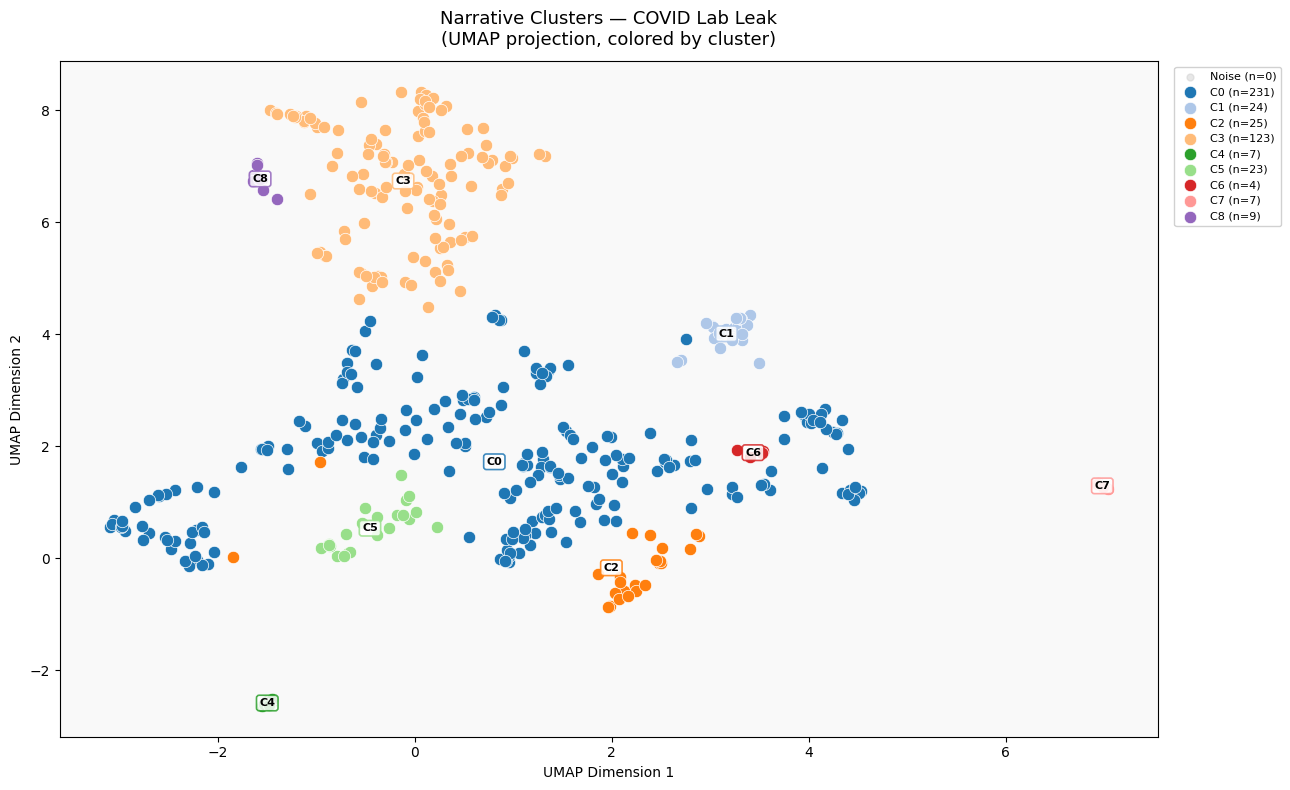

Plot saved -> /content/drive/MyDrive/misinformation-tracker/data/raw/../clusters_umap.png


In [ ]:
#  Step 6: Cluster into Narratives (tuned)

import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import matplotlib.cm as cm

!pip install -q umap-learn
import umap

#  1. Normalize embeddings
embeddings_norm = normalize(embeddings, norm="l2")

#  2. UMAP reduction
# Reduces 384 dims → 10 dims, preserving local semantic structure
# We use 10D for clustering (not 2D — more information retained)
# and separately reduce to 2D just for the plot
print("Running UMAP (this takes ~20 seconds)...")
reducer_10d = umap.UMAP(n_components=10, n_neighbors=10, min_dist=0.0,
                         metric="cosine", random_state=42)
embeddings_umap = reducer_10d.fit_transform(embeddings_norm)

reducer_2d = umap.UMAP(n_components=2, n_neighbors=10, min_dist=0.1,
                        metric="cosine", random_state=42)
coords_2d = reducer_2d.fit_transform(embeddings_norm)

print("UMAP done.")

#  3. DBSCAN on 10D UMAP space
# eps=0.7 is looser than before — captures more articles into clusters
# Tune: raise eps if too much noise, lower if clusters are too big/mixed
dbscan = DBSCAN(eps=0.7, min_samples=2, metric="euclidean")
labels = dbscan.fit_predict(embeddings_umap)

df_clean["cluster"] = labels
df_clean["x"]       = coords_2d[:, 0]
df_clean["y"]       = coords_2d[:, 1]

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = list(labels).count(-1)

print(f"\nClusters found : {n_clusters}")
print(f"Noise articles : {n_noise} ({round(n_noise/len(labels)*100)}%)")
print(f"Clustered      : {len(df_clean) - n_noise} / {len(df_clean)} articles")

#  4. Cluster summaries
print("\n── Cluster Summaries ──────────────────────────────────────────────────")
for cluster_id in sorted(set(labels)):
    if cluster_id == -1:
        continue
    cluster_df = df_clean[df_clean["cluster"] == cluster_id]
    windows    = sorted(cluster_df["window"].unique())
    print(f"\nCluster {cluster_id}  ({len(cluster_df)} articles | windows: {', '.join(windows)})")
    for _, row in cluster_df.head(3).iterrows():
        print(f"  [{row['window']}] {row['title'][:85]}")

#  5. Plot
fig, ax = plt.subplots(figsize=(13, 8))

# Noise points first (background)
noise = df_clean[df_clean["cluster"] == -1]
ax.scatter(noise["x"], noise["y"], c="#d0d0d0", s=25,
           alpha=0.5, label=f"Noise (n={len(noise)})", zorder=1)

# Clustered points
colors = cm.tab20.colors
for cluster_id in sorted(set(labels)):
    if cluster_id == -1:
        continue
    group  = df_clean[df_clean["cluster"] == cluster_id]
    color  = colors[cluster_id % len(colors)]
    ax.scatter(group["x"], group["y"], color=color, s=80,
               edgecolors="white", linewidths=0.5,
               label=f"C{cluster_id} (n={len(group)})", zorder=2)

    # Label at centroid
    cx, cy = group["x"].mean(), group["y"].mean()
    ax.annotate(f"C{cluster_id}", (cx, cy), fontsize=8, fontweight="bold",
                ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.25", fc="white",
                          ec=color, linewidth=1.2, alpha=0.85))

ax.set_title("Narrative Clusters — COVID Lab Leak\n(UMAP projection, colored by cluster)",
             fontsize=13, pad=12)
ax.set_xlabel("UMAP Dimension 1", fontsize=10)
ax.set_ylabel("UMAP Dimension 2", fontsize=10)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, framealpha=0.9)
ax.set_facecolor("#f9f9f9")
plt.tight_layout()

plot_path = f"{DRIVE_DATA_DIR}/../clusters_umap.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved -> {plot_path}")

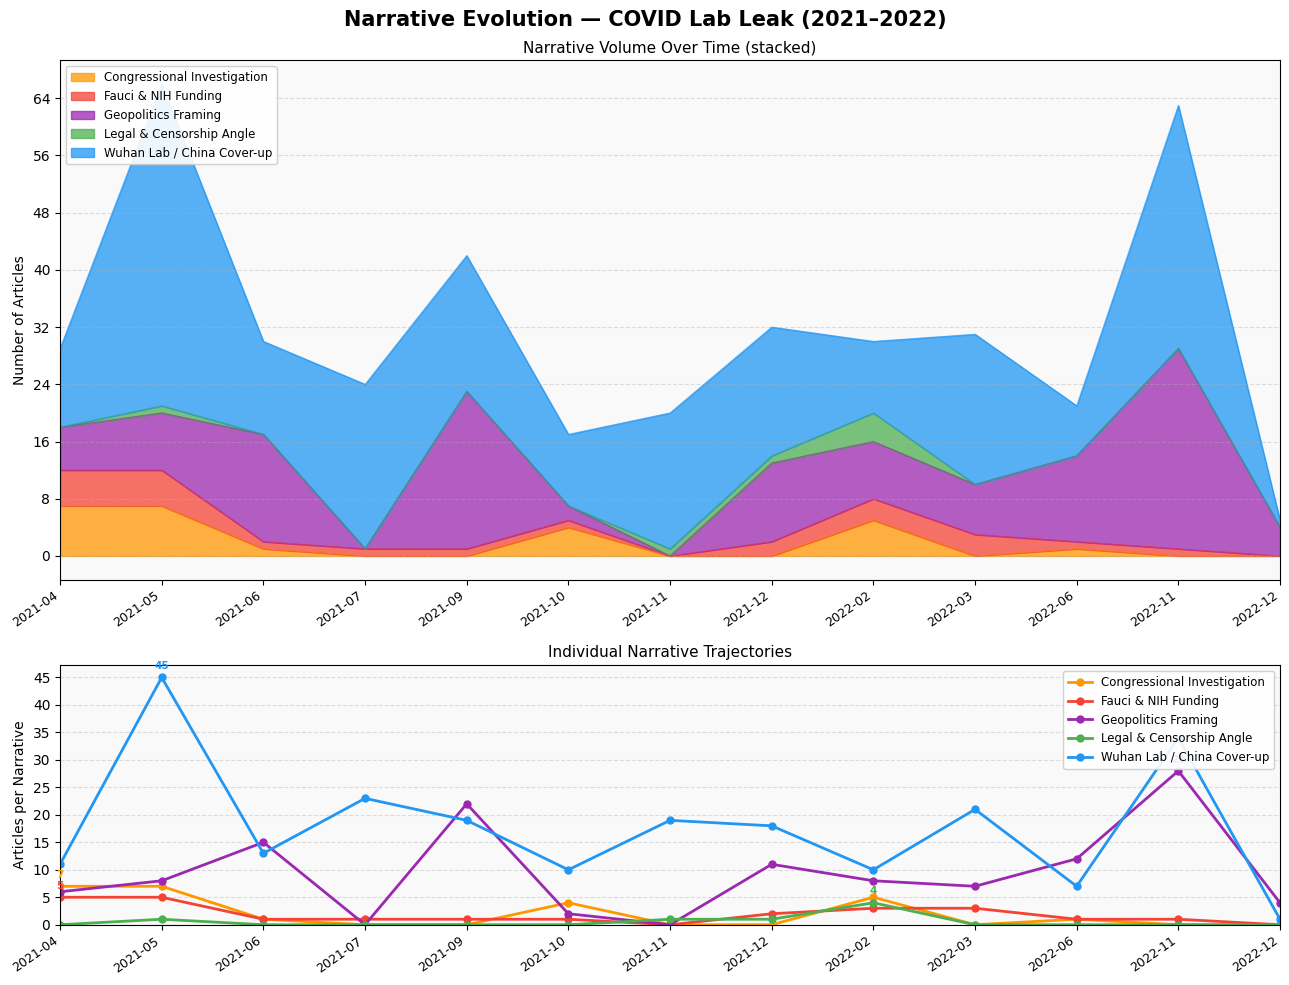

Timeline saved -> /content/drive/MyDrive/misinformation-tracker/data/raw/../timeline.png

── Narrative Activity Summary ─────────────────────────────────────────
Narrative                            Total   First Seen   Peak Month
----------------------------------------------------------------------
Congressional Investigation             25      2021-04      2021-04
Fauci & NIH Funding                     24      2021-04      2021-04
Geopolitics Framing                    123      2021-04      2022-11
Legal & Censorship Angle                 7      2021-05      2022-02
Wuhan Lab / China Cover-up             231      2021-04      2021-05


In [ ]:
#  Step 7: Narrative Evolution Timeline

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

#  Name the clusters based on what we observed
CLUSTER_NAMES = {
    0: "Wuhan Lab / China Cover-up",
    1: "Fauci & NIH Funding",
    2: "Congressional Investigation",
    3: "Geopolitics Framing",
    4: "Legal & Censorship Angle",
}

df_clean["cluster_name"] = df_clean["cluster"].map(CLUSTER_NAMES)

#  Build monthly counts per cluster
all_windows = sorted(df_clean["window"].unique())
pivot = (
    df_clean.groupby(["window", "cluster_name"])
    .size()
    .unstack(fill_value=0)
    .reindex(all_windows, fill_value=0)
)

#  Figure: two panels
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 10),
                                gridspec_kw={"height_ratios": [2, 1]})
fig.suptitle("Narrative Evolution — COVID Lab Leak (2021–2022)",
             fontsize=15, fontweight="bold", y=0.98)

COLORS = {
    "Wuhan Lab / China Cover-up":    "#2196F3",
    "Fauci & NIH Funding":           "#F44336",
    "Congressional Investigation":   "#FF9800",
    "Geopolitics Framing":           "#9C27B0",
    "Legal & Censorship Angle":      "#4CAF50",
}

x = np.arange(len(all_windows))

#  Panel 1: Stacked area chart
baseline = np.zeros(len(all_windows))
for name in pivot.columns:
    values = pivot[name].values
    color  = COLORS.get(name, "grey")
    ax1.fill_between(x, baseline, baseline + values,
                     alpha=0.75, color=color, label=name)
    ax1.plot(x, baseline + values, color=color, linewidth=0.8, alpha=0.5)
    baseline += values

ax1.set_xticks(x)
ax1.set_xticklabels(all_windows, rotation=35, ha="right", fontsize=9)
ax1.set_ylabel("Number of Articles", fontsize=10)
ax1.set_title("Narrative Volume Over Time (stacked)", fontsize=11, pad=6)
ax1.legend(loc="upper left", fontsize=8.5, framealpha=0.9)
ax1.set_xlim(0, len(x) - 1)
ax1.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax1.set_facecolor("#f9f9f9")
ax1.grid(axis="y", linestyle="--", alpha=0.4)

#  Panel 2: Line chart — each narrative independently
for name in pivot.columns:
    color  = COLORS.get(name, "grey")
    values = pivot[name].values
    ax2.plot(x, values, marker="o", markersize=5, linewidth=2,
             color=color, label=name)

    # Annotate the peak month for each narrative
    peak_idx = np.argmax(values)
    if values[peak_idx] > 0:
        ax2.annotate(f"{values[peak_idx]}",
                     (x[peak_idx], values[peak_idx]),
                     textcoords="offset points", xytext=(0, 6),
                     fontsize=7.5, color=color, ha="center", fontweight="bold")

ax2.set_xticks(x)
ax2.set_xticklabels(all_windows, rotation=35, ha="right", fontsize=9)
ax2.set_ylabel("Articles per Narrative", fontsize=10)
ax2.set_title("Individual Narrative Trajectories", fontsize=11, pad=6)
ax2.set_xlim(0, len(x) - 1)
ax2.set_ylim(bottom=0)
ax2.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax2.set_facecolor("#f9f9f9")
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.legend(loc="upper right", fontsize=8.5, framealpha=0.9)

plt.tight_layout()
plot_path = f"{DRIVE_DATA_DIR}/../timeline.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Timeline saved -> {plot_path}")

# Text summary
print("\n── Narrative Activity Summary ─────────────────────────────────────────")
print(f"{'Narrative':<35} {'Total':>6}  {'First Seen':>11}  {'Peak Month':>11}")
print("-" * 70)
for name in pivot.columns:
    total      = pivot[name].sum()
    active     = pivot[name][pivot[name] > 0]
    first_seen = active.index[0]  if len(active) > 0 else "—"
    peak_month = active.idxmax() if len(active) > 0 else "—"
    print(f"{name:<35} {total:>6}  {first_seen:>11}  {peak_month:>11}")

In [ ]:
# Install dashboard dependencies
!pip install -q streamlit pyngrok plotly

# Save the clustered dataframe to Drive so the dashboard can load it
# (in case it needs to reload without re-running the whole pipeline)
df_clean.to_csv(f"{DRIVE_DATA_DIR}/../dashboard_data.csv", index=False)
print("Dashboard data saved.")
print(f"Rows: {len(df_clean)} | Columns: {list(df_clean.columns)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 13.8 MB/s eta 0:00:00
Dashboard data saved.
Rows: 453 | Columns: ['id', 'domain', 'title', 'full_text', 'language', 'url', 'created_utc', 'window', 'clean_text', 'cluster', 'x', 'y', 'cluster_name']


In [ ]:
app_code = '''
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import os
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer

nlp = spacy.load("en_core_web_sm")

#  Page config
st.set_page_config(
    page_title="Narrative Misinformation Tracker",
    page_icon="🔍",
    layout="wide"
)

DRIVE_PATH = "/content/drive/MyDrive/misinformation-tracker/data/raw/../dashboard_data.csv"

COLORS = {
    "Wuhan Lab / China Cover-up":    "#2196F3",
    "Fauci & NIH Funding":           "#F44336",
    "Congressional Investigation":   "#FF9800",
    "Geopolitics Framing":           "#9C27B0",
    "Legal & Censorship Angle":      "#4CAF50",
}

#  Load data
@st.cache_data
def load_data():
    df = pd.read_csv(DRIVE_PATH)

    df["cluster_name"] = df["cluster_name"].fillna("Unknown")
    df["window"] = df["window"].fillna("Unknown")

    return df

df = load_data()

#  Sidebar
st.sidebar.title("🔍 Narrative Tracker")
st.sidebar.markdown("**Case study:** COVID-19 Lab Leak")
st.sidebar.markdown("---")

all_clusters = sorted(
    df["cluster_name"]
    .dropna()
    .astype(str)
    .unique()
)
selected       = st.sidebar.multiselect(
    "Filter by narrative cluster:",
    options=all_clusters,
    default=all_clusters
)

all_windows = sorted(
    df["window"]
    .dropna()
    .astype(str)
    .unique()
)
window_range = st.sidebar.select_slider(
    "Date range:",
    options=all_windows,
    value=(all_windows[0], all_windows[-1])
)

st.sidebar.markdown("---")
st.sidebar.markdown(f"**Total articles:** {len(df)}")
st.sidebar.markdown(f"**Clusters:** {df['cluster_name'].nunique()}")
st.sidebar.markdown(f"**Domains:** {df['domain'].nunique()}")

#  Filter data
start_idx = all_windows.index(window_range[0])
end_idx   = all_windows.index(window_range[1])
windows_in_range = all_windows[start_idx:end_idx + 1]

df_filtered = df[
    (df["cluster_name"].isin(selected)) &
    (df["window"].isin(windows_in_range))
]

#  Header
st.title("🔍 Narrative Misinformation Tracking System")
st.markdown(
    "Tracking how the **COVID-19 lab leak narrative** evolved across "
    "658 news outlets between January 2021 and October 2022."
)

#  KPI row
k1, k2, k3, k4 = st.columns(4)
k1.metric("Articles (filtered)", len(df_filtered))
k2.metric("Narratives", df_filtered["cluster_name"].nunique())
k3.metric("Unique Domains", df_filtered["domain"].nunique())
k4.metric("Time Windows", df_filtered["window"].nunique())

st.markdown("---")

#  Tab layout
tab1, tab2, tab3, tab4, tab5 = st.tabs([
    "📈 Timeline", "🗺️ Cluster Map", "📰 Article Browser", "📊 Domain Analysis", "🧬 Mutation View"
])

# ════════════════════════════════════════════════════════════════════════════
# TAB 1 — Timeline
# ════════════════════════════════════════════════════════════════════════════
with tab1:
    st.subheader("Narrative Volume Over Time")

    pivot = (
        df_filtered.groupby(["window", "cluster_name"])
        .size()
        .reset_index(name="count")
    )

    # Stacked area chart
    fig_area = px.area(
        pivot, x="window", y="count", color="cluster_name",
        color_discrete_map=COLORS,
        labels={"window": "Month", "count": "Articles", "cluster_name": "Narrative"},
        title="Total Narrative Volume (stacked)",
    )
    fig_area.update_layout(
        hovermode="x unified", legend_title="Narrative",
        xaxis_tickangle=-35, height=380,
        plot_bgcolor="#f9f9f9"
    )
    st.plotly_chart(fig_area, use_container_width=True)

    # Line chart
    fig_line = px.line(
        pivot, x="window", y="count", color="cluster_name",
        color_discrete_map=COLORS, markers=True,
        labels={"window": "Month", "count": "Articles", "cluster_name": "Narrative"},
        title="Individual Narrative Trajectories",
    )
    fig_line.update_layout(
        hovermode="x unified", legend_title="Narrative",
        xaxis_tickangle=-35, height=380,
        plot_bgcolor="#f9f9f9"
    )
    st.plotly_chart(fig_line, use_container_width=True)

    # Summary table
    st.subheader("Narrative Activity Summary")
    summary_rows = []
    for name in selected:
        subset = df_filtered[df_filtered["cluster_name"] == name]
        if len(subset) == 0:
            continue
        by_window = subset.groupby("window").size()
        summary_rows.append({
            "Narrative":   name,
            "Total":       len(subset),
            "First Seen":  by_window.index[0],
            "Peak Month":  by_window.idxmax(),
            "Peak Count":  int(by_window.max()),
        })
    st.dataframe(pd.DataFrame(summary_rows), use_container_width=True, hide_index=True)

# ════════════════════════════════════════════════════════════════════════════
# TAB 2 — Cluster Map (UMAP)
# ════════════════════════════════════════════════════════════════════════════
with tab2:
    st.subheader("Semantic Cluster Map (UMAP projection)")
    st.markdown(
        "Each dot is one article. Articles close together are semantically similar. "
        "Colour = narrative cluster."
    )

    fig_umap = px.scatter(
        df_filtered, x="x", y="y",
        color="cluster_name",
        color_discrete_map=COLORS,
        hover_data={"title": True, "window": True, "domain": True,
                    "x": False, "y": False},
        labels={"cluster_name": "Narrative"},
        height=550,
    )
    fig_umap.update_traces(marker=dict(size=7, opacity=0.8, line=dict(width=0.3, color="white")))
    fig_umap.update_layout(
        plot_bgcolor="#f9f9f9",
        legend_title="Narrative",
        xaxis_title="UMAP Dimension 1",
        yaxis_title="UMAP Dimension 2",
    )
    st.plotly_chart(fig_umap, use_container_width=True)

# ════════════════════════════════════════════════════════════════════════════
# TAB 3 — Article Browser
# ════════════════════════════════════════════════════════════════════════════
with tab3:
    st.subheader("Article Browser")

    col1, col2 = st.columns(2)
    cluster_filter = col1.selectbox("Cluster", ["All"] + all_clusters)
    window_filter  = col2.selectbox("Month", ["All"] + all_windows)

    view = df_filtered.copy()
    if cluster_filter != "All":
        view = view[view["cluster_name"] == cluster_filter]
    if window_filter != "All":
        view = view[view["window"] == window_filter]

    st.markdown(f"Showing **{len(view)}** articles")
    st.dataframe(
        view[["window", "cluster_name", "domain", "title", "url"]]
            .sort_values(["window", "cluster_name"])
            .rename(columns={
                "window":       "Month",
                "cluster_name": "Narrative",
                "domain":       "Domain",
                "title":        "Title",
                "url":          "URL",
            }),
        use_container_width=True,
        hide_index=True,
    )

# ════════════════════════════════════════════════════════════════════════════
# TAB 4 — Domain Analysis
# ════════════════════════════════════════════════════════════════════════════
with tab4:
    st.subheader("Top Domains by Narrative")

    col_a, col_b = st.columns(2)

    # Top domains overall
    top_domains = (
        df_filtered.groupby("domain").size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(20)
    )
    fig_dom = px.bar(
        top_domains, x="count", y="domain", orientation="h",
        title="Top 20 Domains (all narratives)",
        labels={"count": "Articles", "domain": "Domain"},
        height=500,
        color="count", color_continuous_scale="Blues"
    )
    fig_dom.update_layout(yaxis=dict(autorange="reversed"), plot_bgcolor="#f9f9f9")
    col_a.plotly_chart(fig_dom, use_container_width=True)

    # Per-cluster domain breakdown
    selected_cluster = col_b.selectbox("Cluster for domain breakdown:", all_clusters, key="dom_cluster")
    cluster_domains  = (
        df_filtered[df_filtered["cluster_name"] == selected_cluster]
        .groupby("domain").size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(15)
    )
    fig_cd = px.bar(
        cluster_domains, x="count", y="domain", orientation="h",
        title=f"Top Domains — {selected_cluster}",
        labels={"count": "Articles", "domain": "Domain"},
        height=500,
        color="count",
        color_discrete_sequence=[COLORS.get(selected_cluster, "#888")]
    )
    fig_cd.update_layout(yaxis=dict(autorange="reversed"), plot_bgcolor="#f9f9f9")
    col_b.plotly_chart(fig_cd, use_container_width=True)

# ════════════════════════════════════════════════════════════════════════════
# TAB 5 — Mutation Analysis
# ════════════════════════════════════════════════════════════════════════════
# ── NER filter (defined once, used in Tab 5) ─────────────────────────────────
# Put this function near the top of app.py, after `nlp = spacy.load(...)`.
# Strips PERSON, ORG, GPE, FAC entities so TF-IDF sees narrative vocabulary,
# not anchor names like "Watters" or "Alyssa Farah".

def strip_named_entities(text: str) -> str:
    """
    Remove named entities (people, orgs, places, facilities) from a title.
    Keeps content words relevant to narrative framing.
    """
    doc = nlp(text)
    blocked_ent_types = {"PERSON", "ORG", "GPE", "FAC", "NORP"}
    # Collect entity char spans to skip
    blocked_spans = set()
    for ent in doc.ents:
        if ent.label_ in blocked_ent_types:
            for i in range(ent.start, ent.end):
                blocked_spans.add(i)
    # Keep tokens that are: not a named entity, not a stopword, alphabetic, >2 chars
    tokens = [
        token.lemma_.lower()
        for token in doc
        if token.i not in blocked_spans
        and not token.is_stop
        and token.is_alpha
        and len(token.text) > 2
    ]
    return " ".join(tokens)


#  Tab 5

with tab5:
    st.subheader("🧬 Narrative Mutation View")
    st.markdown(
        "How does the **vocabulary** of a narrative shift month by month? "
        "Each column is a month. Each row is a term. "
        "Darker = more distinctive to that cluster in that month (TF-IDF score). "
        "Named entities (people, outlets, places) are stripped so only "
        "**framing language** shows up."
    )

    #  Controls
    col_m1, col_m2 = st.columns([2, 1])

    selected_cluster_mut = col_m1.selectbox(
        "Select narrative cluster:",
        options=all_clusters,
        key="mutation_cluster"
    )

    top_n = col_m2.slider(
        "Terms per month:",
        min_value=5,
        max_value=20,
        value=10,
        key="mutation_topn"
    )

    #  Filter to selected cluster + date range
    cluster_df = df[
        (df["cluster_name"] == selected_cluster_mut) &
        (df["window"].isin(windows_in_range))
    ].copy()

    if len(cluster_df) < 3:
        st.warning(
            "Not enough articles in this cluster for the selected date range. "
            "Widen the date range or pick a larger cluster."
        )
    else:
        #  Strip named entities from titles
        # Cache the cleaned text so re-running the tab doesn't re-run spaCy
        @st.cache_data(show_spinner="Stripping named entities…")
        def clean_titles_for_cluster(titles: list) -> list:
            return [strip_named_entities(t) for t in titles]

        cluster_df["clean_title_ner"] = clean_titles_for_cluster(
            cluster_df["title"].fillna("").astype(str).tolist()
        )

        #  Group by month
        monthly_text = (
            cluster_df.groupby("window")["clean_title_ner"]
            .apply(lambda texts: " ".join(texts))
            .reset_index()
        )
        monthly_text.columns = ["window", "combined_text"]
        monthly_text = (
            monthly_text[monthly_text["combined_text"].str.strip() != ""]
            .sort_values("window")
            .reset_index(drop=True)
        )

        months = monthly_text["window"].tolist()

        if len(months) < 2:
            st.warning(
                "Only one month of data found for this cluster. "
                "Select a wider date range to see mutation."
            )
        else:
            #  TF-IDF
            # Each "document" = one month of concatenated cleaned titles.
            # min_df=2: term must appear in ≥2 articles that month to count.
            # ngram_range=(1,1): unigrams only — bigrams are too noisy on headlines.
            vectorizer = TfidfVectorizer(
                max_features=300,
                ngram_range=(1, 1),
                stop_words="english",
                min_df=2,
                sublinear_tf=True,
            )

            try:
                tfidf_matrix = vectorizer.fit_transform(monthly_text["combined_text"])
            except ValueError:
                st.warning(
                    "Not enough repeated terms across months to compute TF-IDF. "
                    "Try selecting a larger cluster or a wider date range."
                )
                st.stop()

            feature_names = vectorizer.get_feature_names_out()

            # Top-N terms per month
            import numpy as np

            month_top_terms = {}
            for i, month in enumerate(months):
                row = tfidf_matrix[i].toarray().flatten()
                top_indices = row.argsort()[::-1][:top_n]
                month_top_terms[month] = [
                    (feature_names[j], round(float(row[j]), 3))
                    for j in top_indices
                    if row[j] > 0
                ]

            #  Heatmap
            all_top_terms = []
            seen = set()
            for month in months:
                for term, _ in month_top_terms.get(month, []):
                    if term not in seen:
                        all_top_terms.append(term)
                        seen.add(term)

            score_rows = []
            for term in all_top_terms:
                row_data = {"Term": term}
                for month in months:
                    score_dict = dict(month_top_terms.get(month, []))
                    row_data[month] = score_dict.get(term, 0.0)
                score_rows.append(row_data)

            import pandas as pd
            heatmap_df = pd.DataFrame(score_rows).set_index("Term")
            heatmap_df["_total"] = heatmap_df.sum(axis=1)
            heatmap_df = heatmap_df.sort_values("_total", ascending=False).drop(columns="_total")

            import plotly.graph_objects as go

            z_values = heatmap_df.values
            terms    = heatmap_df.index.tolist()

            hover_text = [
                [
                    f"<b>{term}</b><br>Month: {month}<br>TF-IDF: {z_values[i][j]:.3f}"
                    for j, month in enumerate(months)
                ]
                for i, term in enumerate(terms)
            ]

            fig_mut = go.Figure(data=go.Heatmap(
                z=z_values,
                x=months,
                y=terms,
                text=hover_text,
                hoverinfo="text",
                colorscale="Blues",
                showscale=True,
                colorbar=dict(title="TF-IDF", thickness=14),
                zmin=0,
            ))

            fig_mut.update_layout(
                title=f"Term Distinctiveness by Month — {selected_cluster_mut}",
                xaxis=dict(title="Month", tickangle=-35, side="top"),
                yaxis=dict(title="", autorange="reversed"),
                height=max(400, len(terms) * 22 + 120),
                margin=dict(l=180, r=60, t=100, b=40),
                plot_bgcolor="#f9f9f9",
            )

            st.plotly_chart(fig_mut, use_container_width=True)

            #  Month-by-month term lists
            st.markdown("---")
            st.subheader("Top Distinctive Terms by Month")
            st.markdown(
                "Ranked by how *uniquely* each term characterizes that month "
                "within this narrative — not raw frequency."
            )

            cols_per_row = 3
            month_cols = st.columns(min(cols_per_row, len(months)))

            for i, month in enumerate(months):
                col = month_cols[i % cols_per_row]
                terms_this_month = month_top_terms.get(month, [])
                n_articles = len(cluster_df[cluster_df["window"] == month])

                with col:
                    st.markdown(f"**{month}** *(n={n_articles})*")
                    if terms_this_month:
                        max_score = terms_this_month[0][1] if terms_this_month[0][1] > 0 else 1
                        for rank, (term, score) in enumerate(terms_this_month, 1):
                            bar_width = int((score / max_score) * 12)
                            bar = "█" * bar_width + "░" * (12 - bar_width)
                            st.markdown(
                                f"<span style='font-size:0.78rem; font-family:monospace'>"
                                f"{rank:2}. {bar} {term}</span>",
                                unsafe_allow_html=True,
                            )
                    else:
                        st.markdown("*No terms (too few repeated words)*")

                if (i + 1) % cols_per_row == 0 and (i + 1) < len(months):
                    month_cols = st.columns(min(cols_per_row, len(months) - (i + 1)))

            #  Vocabulary shift panel
            st.markdown("---")
            st.subheader("Vocabulary Shift: Early vs Late")
            st.markdown(
                "Terms prominent in the first half of the timeline vs the second half. "
                "Shows when the narrative reframed — e.g. from scientific debate to "
                "political or legal framing."
            )

            mid          = len(months) // 2
            early_months = months[:mid]
            late_months  = months[mid:]

            early_terms = set()
            late_terms  = set()
            for m in early_months:
                for term, _ in month_top_terms.get(m, []):
                    early_terms.add(term)
            for m in late_months:
                for term, _ in month_top_terms.get(m, []):
                    late_terms.add(term)

            only_early = sorted(early_terms - late_terms)
            only_late  = sorted(late_terms - early_terms)
            both       = sorted(early_terms & late_terms)

            c1, c2, c3 = st.columns(3)

            with c1:
                early_label = (
                                  f"**🟦 Early only**  \\n"
                                  f"_{early_months[0]} – {early_months[-1]}_"
                              )
                st.markdown(early_label)
                st.markdown(
                    "<br>".join(f"• {t}" for t in only_early) or "*None*",
                    unsafe_allow_html=True,
                )

            with c2:
                late_label = (
                                  f"**🟩 Late only**  \\n"
                                  f"_{late_months[0]} – {late_months[-1]}_"
                              )
                st.markdown(late_label)
                st.markdown(
                    "<br>".join(f"• {t}" for t in only_late) or "*None*",
                    unsafe_allow_html=True,
                )

            with c3:
                st.markdown("**⬜ Persistent** *(both periods)*")
                st.markdown(
                    "<br>".join(f"• {t}" for t in both[:15]) or "*None*",
                    unsafe_allow_html=True,
                )
'''

with open("/content/app.py", "w") as f:
    f.write(app_code)

print("app.py written.")

app.py written.


**For below visualization to run via ngrok, user will have to create an ngrok account and use their token in place of "YOUR TOKEN"**

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("YOUR TOKEN")

In [ ]:
import subprocess
import time
from pyngrok import ngrok

ngrok.set_auth_token("YOUR TOKEN")

ngrok.kill()

proc = subprocess.Popen(
    [
        "streamlit", "run", "/content/app.py",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false"
    ]
)

time.sleep(5)

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://decal-surcharge-curtly.ngrok-free.dev" -> "http://localhost:8501"
